In [2]:
what_we_cover = {
    1:"data",
    2:"build the model",
    3:"fitting in the model",
    4:"making pedictons and evaluating the model",
    5:"saving and loading the model",
    6:"putting it all together"
}
print(what_we_cover)

{1: 'data', 2: 'build the model', 3: 'fitting in the model', 4: 'making pedictons and evaluating the model', 5: 'saving and loading the model', 6: 'putting it all together'}


In [3]:
import torch as tr
from torch import nn
import matplotlib.pyplot as plt
print(tr.__version__)

2.12.1+cu132


In [4]:
##  Data Preparing and Loading

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
x = tr.arange(start, end, step).unsqueeze(dim=1)
print(x)
y = weight * x + bias
y, len(y), len(x)

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])


(tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [0.4680],
         [0.4820],
         [0.4960],
         [0.5100],
         [0.5240],
         [0.5380],
         [0.5520],
         [0.5660],
         [0.5800],
         [0.5940],
         [0.6080],
         [0.6220],
         [0.6360],
         [0.6500],
         [0.6640],
         [0.6780],
         [0.6920],
         [0.7060],
         [0.7200],
         [0.7340],
         [0.7480],
         [0.7620],
         [0.7760],
         [0.7900],
         [0.8040],
         [0.8180],
         [0.8320],
         [0.8460],
         [0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]),
 50,
 50)

In [5]:
train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]
print(len(x_train), len(y_train), len(x_test), len(y_test))

40 40 10 10


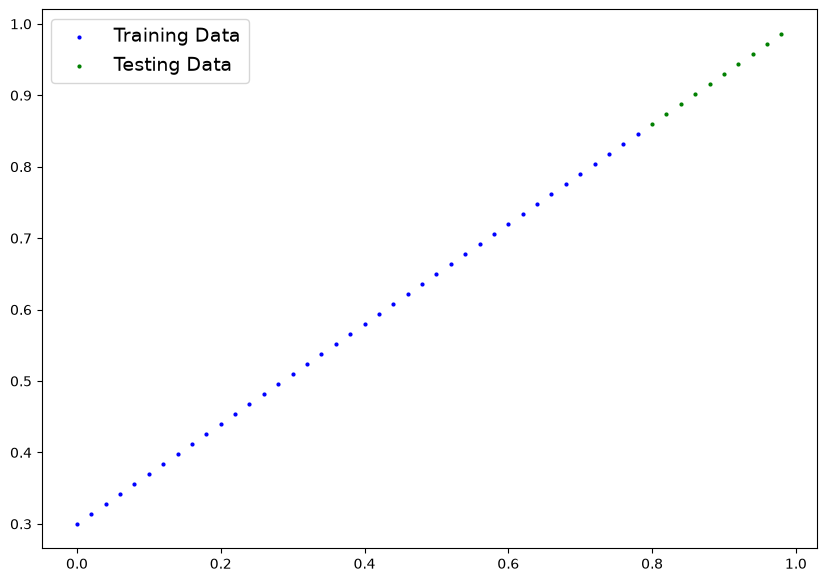

In [6]:
## Visualizing the data using matplotlib


def plot_predictions(train_data = x_train, 
                     train_Labels = y_train,
                     test_data = x_test,
                     test_Labels = y_test,
                     predictions = None):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_Labels, c="b", s=4, label = "Training Data")
    plt.scatter(test_data, test_Labels, c="g", s=4, label = "Testing Data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c = "r", s = 4, label = "Predicted Data")

    plt.legend(prop = {"size": 14});

plot_predictions()

In [7]:
## Building the First AI Model

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(tr.randn(1, requires_grad = True, dtype = tr.float))
        self.bias = nn.Parameter(tr.randn(1, requires_grad = True, dtype = tr.float))
        

    def forward(self, x: tr.Tensor)-> tr.Tensor:
            return self.weights * x + self.bias

model = LinearRegressionModel()
model.state_dict()

OrderedDict([('weights', tensor([0.2957])), ('bias', tensor([0.4009]))])

In [8]:
## Contents of a PyTorch Model


tr.manual_seed(42)
model_0 = LinearRegressionModel()

model_0.eval()
model_0.parameters()
list(model_0.parameters())



[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
y_preds = model_0(x_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [10]:
## usage of torch.inference 


with tr.inference_mode():
    y_preds = model_0(x_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

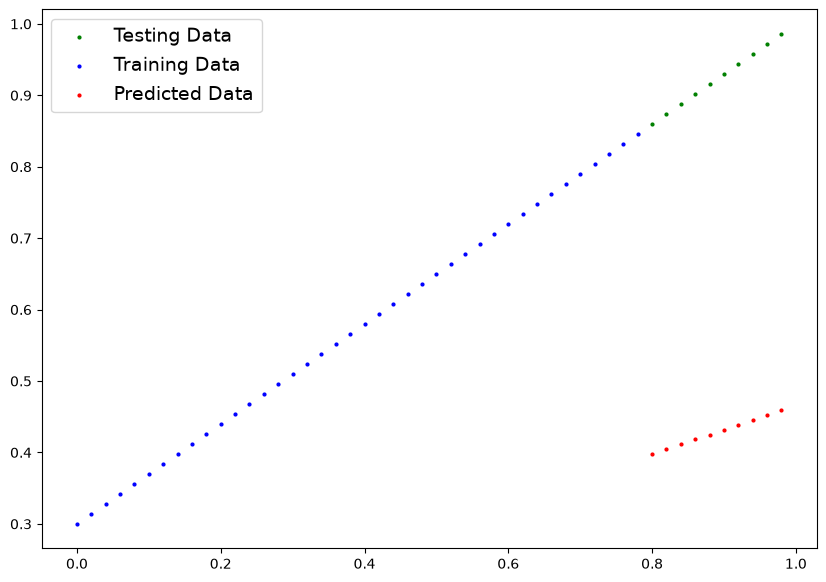

In [11]:
y_test
plt.figure(figsize=(10, 7))
plt.scatter(x_test, y_test, c = "g", s = 4, label = "Testing Data")
plt.scatter(x_train, y_train, c = "b", s = 4, label = "Training Data")
plt.scatter(x_test, y_preds, c = "r", s = 4, label = "Predicted Data")
plt.legend(prop = {"size": 14})

In [12]:
## Loss Function and Optimizer

loss_fn = nn.L1Loss()
optimizer = tr.optim.SGD(params=model_0.parameters(),
                         lr = 0.001,
                         momentum = 0.9)


In [13]:
## Building a training Loop
tr.manual_seed(42)
list(model_0.parameters())


epochs = 10
## track the count of values 
epoch_count = []
loss_values = []
test_loss_values = []


for epoch in range(epochs):
    model_0.train()
    ## Forward pass
    y_preds  = model_0(x_train)
    ### Calculate the loss
    loss = loss_fn(y_preds, y_train)
    print(f"Loss:{loss}")
    ## optimizer zero grad
    optimizer.zero_grad()
    ## loss backward
    loss.backward()
    ## optimizer step
    optimizer.step()

    model_0.eval()
    with tr.inference_mode():
        test_pred = model_0(x_test)
        test_loss = loss_fn(test_pred, y_test)
    

    # print(model_0.state_dict())
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    if epoch % 10 == 0:
        
        print(f"epoch: {epoch} | loss: {loss} | test Loss: {test_loss}" )
    

Loss:0.31288138031959534
epoch: 0 | loss: 0.31288138031959534 | test Loss: 0.4931890368461609
Loss:0.3117292523384094
Loss:0.3095402121543884
Loss:0.3064180612564087
Loss:0.30245599150657654
Loss:0.2977380156517029
Loss:0.2923397421836853
Loss:0.2863292098045349
Loss:0.27976763248443604
Loss:0.27271008491516113


In [14]:
loss_values, test_loss_values

([tensor(0.3129, grad_fn=<MeanBackward0>),
  tensor(0.3117, grad_fn=<MeanBackward0>),
  tensor(0.3095, grad_fn=<MeanBackward0>),
  tensor(0.3064, grad_fn=<MeanBackward0>),
  tensor(0.3025, grad_fn=<MeanBackward0>),
  tensor(0.2977, grad_fn=<MeanBackward0>),
  tensor(0.2923, grad_fn=<MeanBackward0>),
  tensor(0.2863, grad_fn=<MeanBackward0>),
  tensor(0.2798, grad_fn=<MeanBackward0>),
  tensor(0.2727, grad_fn=<MeanBackward0>)],
 [tensor(0.4932),
  tensor(0.4906),
  tensor(0.4870),
  tensor(0.4823),
  tensor(0.4768),
  tensor(0.4705),
  tensor(0.4635),
  tensor(0.4558),
  tensor(0.4476),
  tensor(0.4388)])

C:\Users\dynam\AppData\Local\Temp\ipykernel_6820\3744627478.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  plt.plot(epoch_count, np.array(tr.tensor(loss_values) .numpy()), label="Train loss")


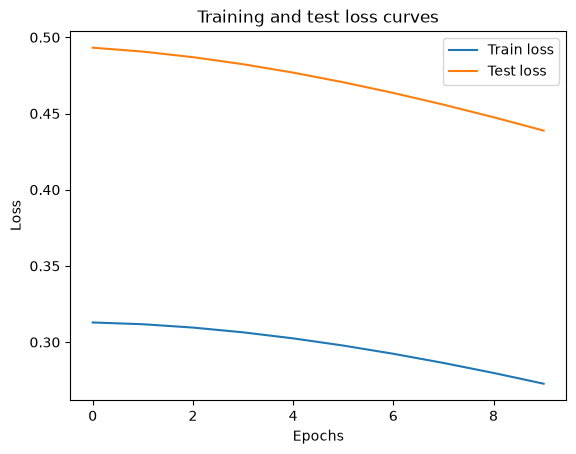

In [15]:
import numpy as np

plt.plot(epoch_count, np.array(tr.tensor(loss_values) .numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [16]:
with tr.inference_mode():
    y_preds_new = model_0(x_test)

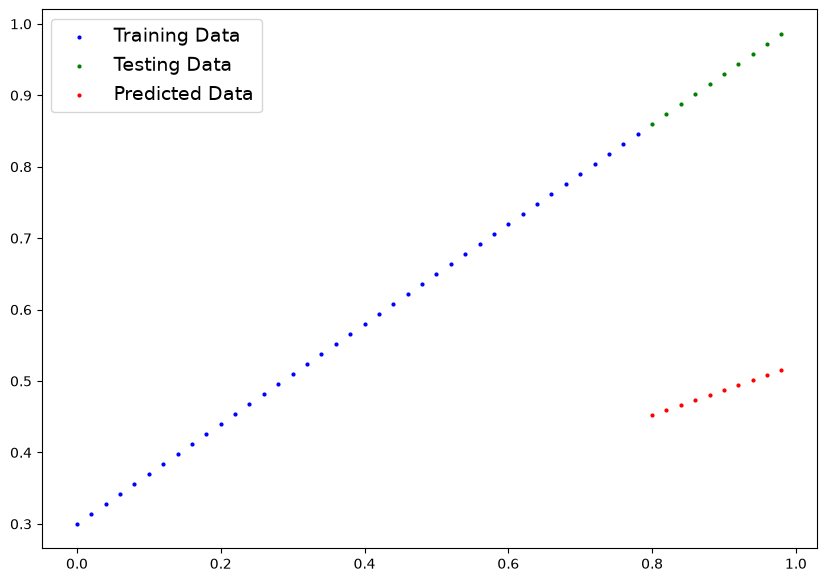

In [17]:
plot_predictions(predictions=y_preds_new)

## saving and loading model in pytorch 

1. torch.save
2. torch.load
3. torch.nn.Module.load_state_dict()

In [18]:
## creating a model directory 
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok = True)

MODEL_NAME = "01.Pytorch_workflow.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to : {MODEL_SAVE_PATH}")
tr.save(model_0.state_dict(), f= MODEL_SAVE_PATH)


Saving model to : models\01.Pytorch_workflow.pth


In [19]:
##loading pytorch model

model = LinearRegressionModel()
model.load_state_dict(tr.load(f=MODEL_SAVE_PATH))


print(model)
print(f"Model loaded from: {MODEL_SAVE_PATH}")

LinearRegressionModel()
Model loaded from: models\01.Pytorch_workflow.pth


In [20]:
model.eval()
with tr.inference_mode():
    loaded_model_preds = model(x_test)

loaded_model_preds



tensor([[0.4525],
        [0.4595],
        [0.4666],
        [0.4736],
        [0.4807],
        [0.4877],
        [0.4948],
        [0.5018],
        [0.5089],
        [0.5160]])

In [21]:
y_preds == loaded_model_preds

RuntimeError: The size of tensor a (40) must match the size of tensor b (10) at non-singleton dimension 0

In [ ]:
## putting it all together

device = "cuda" if tr.cuda.is_available() else "cpu"

print(f"Using device: {device}")





Using device: cuda


In [ ]:
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features = 1, out_features = 1)

    def forward(self, x: tr.Tensor) -> tr.Tensor:
        return self.linear_layer(x)


tr.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
x_train[:5], y_train[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [ ]:
next(model_1.parameters()).device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
optimizer = tr.optim.SGD(params=model_1.parameters(),
                         lr = 0.01)

tr.manual_seed(42)
x_train = x_train.to(device)
y_train = y_train.to(device)
x_test = x_test.to(device)
y_test = y_test.to(device)
epochs = 200
for epoch in range(epochs):
    model_1.train()
    
    y_preds = model_1(x_train)

    loss = loss_fn(y_preds, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_1.eval()

    with tr.inference_mode():
        test_preds = model_1(x_test)
        test_loss = loss_fn(test_preds, y_test)


    if epoch % 10 == 0:
        print(f"epoch: {epoch} | loss: {loss} | test Loss: {test_loss}" )



epoch: 0 | loss: 1.5238697528839111 | test Loss: 1.8132072687149048
epoch: 10 | loss: 1.408659815788269 | test Loss: 1.678497314453125
epoch: 20 | loss: 1.293449878692627 | test Loss: 1.5437872409820557
epoch: 30 | loss: 1.1782399415969849 | test Loss: 1.4090772867202759
epoch: 40 | loss: 1.0630301237106323 | test Loss: 1.274367332458496
epoch: 50 | loss: 0.9478201270103455 | test Loss: 1.1396574974060059
epoch: 60 | loss: 0.8326103091239929 | test Loss: 1.0049476623535156
epoch: 70 | loss: 0.7174004316329956 | test Loss: 0.8702379465103149
epoch: 80 | loss: 0.6021904349327087 | test Loss: 0.7355279326438904
epoch: 90 | loss: 0.4869804084300995 | test Loss: 0.6008180379867554
epoch: 100 | loss: 0.3717704713344574 | test Loss: 0.4661080837249756
epoch: 110 | loss: 0.2565605342388153 | test Loss: 0.3313981890678406
epoch: 120 | loss: 0.14135052263736725 | test Loss: 0.1966882050037384
epoch: 130 | loss: 0.029061144217848778 | test Loss: 0.0661207064986229
epoch: 140 | loss: 0.01468097325

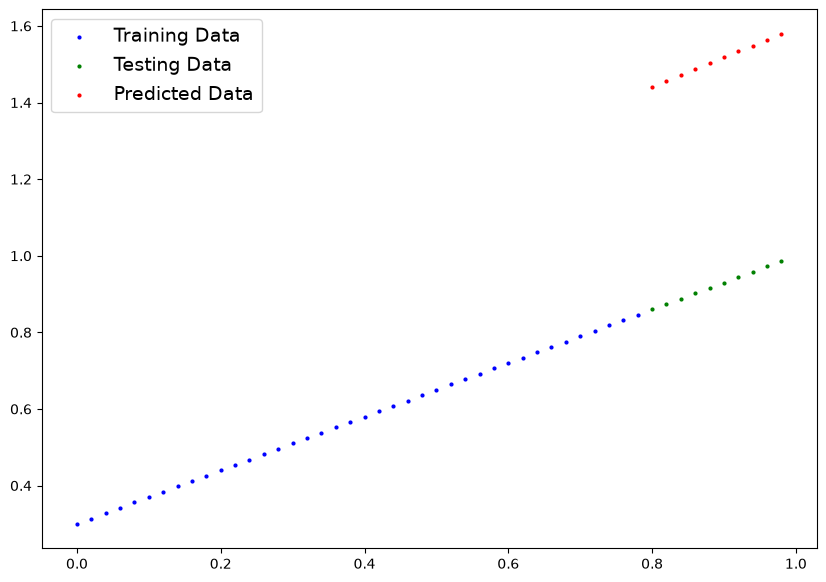

In [ ]:
model_1 = LinearRegressionModelV2().to(device)
x_test = x_test.to(device)

model_1.eval()
with tr.inference_mode():

    y_preds_news = model_1(x_test)


plot_predictions(predictions=y_preds_news.cpu())